# A2 — Manual Min-Max on a Tiny Set

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে একটি ছোট dataset আছে:

$$\text{scores} = [20, 25, 30, 50]$$

কাজ হলো এই scores-গুলোকে **[0, 1]** range-এ **Min-Max Scaling** করতে হবে — এবং **প্রতিটি ধাপ দেখাতে হবে।**


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- Min-Max Scaling-এর **formula কীভাবে কাজ করে** সেটা হাতে হিসাব করে পাকা করব।
- প্রতিটি step আলাদা করে দেখলে formula-র **ভেতরের mechanics** স্পষ্ট হবে।
- Code দিয়ে verify করে নিশ্চিত হব যে হাতের হিসাব সঠিক।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

**Min-Max Scaling formula:**

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

এই formula তিনটি জিনিস করে:

| ধাপ | কাজ | কেন? |
|---|---|---|
| $x - x_{min}$ | প্রতিটি মান থেকে সর্বনিম্ন বাদ দেওয়া | সবচেয়ে ছোট মানকে 0-এ নামিয়ে আনে |
| $x_{max} - x_{min}$ | পুরো range বের করা | data কতটা ছড়িয়ে আছে সেটা মাপে |
| দুটো ভাগ করা | relative position বের করা | 0 থেকে 1-এর মধ্যে নিয়ে আসে |

**Scores = [20, 25, 30, 50]** দেখে:
- $x_{min} = 20$
- $x_{max} = 50$
- $\text{range} = 50 - 20 = 30$


---

## 🛠️ Problem Solve করার Approach

**Step 1:** Data define করা।

**Step 2:** হাতে হিসাব — প্রতিটি মানের জন্য আলাদাভাবে step-by-step দেখানো।

**Step 3:** Code দিয়ে verify করা।

**Step 4:** Visual chart-এ Before vs After দেখা।


## Step 1: Data Define করা

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores = np.array([20, 25, 30, 50], dtype=float)

x_min = scores.min()
x_max = scores.max()
x_range = x_max - x_min

print(f"Scores  : {scores}")
print(f"x_min   : {x_min}")
print(f"x_max   : {x_max}")
print(f"Range   : {x_range}")


Scores  : [20. 25. 30. 50.]
x_min   : 20.0
x_max   : 50.0
Range   : 30.0


`scores.min()` ও `scores.max()` দিয়ে সর্বনিম্ন ও সর্বোচ্চ মান বের করা হয়েছে।
`dtype=float` দেওয়া হয়েছে কারণ ভাগ করলে দশমিক সংখ্যা আসবে।


---

## Step 2: হাতে হিসাব — প্রতিটি মানের জন্য Step-by-Step

$$x_{min} = 20, \quad x_{max} = 50, \quad \text{range} = 30$$

---

### 🔢 Score = 20

$$x' = \frac{20 - 20}{30} = \frac{0}{30} = \mathbf{0.000}$$

→ সবচেয়ে ছোট মান, তাই scaled value = **0** (range-এর শুরু)

---

### 🔢 Score = 25

$$x' = \frac{25 - 20}{30} = \frac{5}{30} = \mathbf{0.167}$$

→ range-এর প্রায় ১/৬ ভাগ উপরে

---

### 🔢 Score = 30

$$x' = \frac{30 - 20}{30} = \frac{10}{30} = \mathbf{0.333}$$

→ range-এর ঠিক ১/৩ ভাগ উপরে

---

### 🔢 Score = 50

$$x' = \frac{50 - 20}{30} = \frac{30}{30} = \mathbf{1.000}$$

→ সবচেয়ে বড় মান, তাই scaled value = **1** (range-এর শেষ)


## Step 3: Code দিয়ে Verify করা

In [3]:
# Manual calculation — step by step
numerators   = scores - x_min
denominators = np.full(len(scores), x_range)
scaled       = numerators / denominators

result = pd.DataFrame({
    'Score (x)':        scores.astype(int),
    'x - x_min':        numerators.astype(int),
    'x_max - x_min':    denominators.astype(int),
    "Scaled (x')":      scaled.round(4)
})

print("── Min-Max Scaling — Step by Step ──")
print(result.to_string(index=False))


── Min-Max Scaling — Step by Step ──
 Score (x)  x - x_min  x_max - x_min  Scaled (x')
        20          0             30       0.0000
        25          5             30       0.1667
        30         10             30       0.3333
        50         30             30       1.0000


`scores - x_min` → প্রতিটি মান থেকে minimum বাদ দেওয়া (NumPy broadcasting)।
`np.full(len(scores), x_range)` → সব row-এর জন্য একই denominator (30) দিয়ে একটি array তৈরি।
`numerators / denominators` → element-wise ভাগ করে scaled value পাওয়া।


In [4]:
from sklearn.preprocessing import MinMaxScaler

sklearn_scaled = MinMaxScaler().fit_transform(scores.reshape(-1, 1)).flatten()

print("Manual scaled :", scaled.round(4))
print("Sklearn scaled:", sklearn_scaled.round(4))
print("Match         :", np.allclose(scaled, sklearn_scaled))


Manual scaled : [0.     0.1667 0.3333 1.    ]
Sklearn scaled: [0.     0.1667 0.3333 1.    ]
Match         : True


`MinMaxScaler().fit_transform()` — sklearn-এর built-in Min-Max Scaling।
`np.allclose()` → দুটো array প্রায় সমান কিনা তা check করে (floating point tolerance সহ)।
`Match: True` মানে হাতের হিসাব ও sklearn-এর result হুবহু মিলেছে। ✅


## Step 4: Visual — Before vs After Scaling

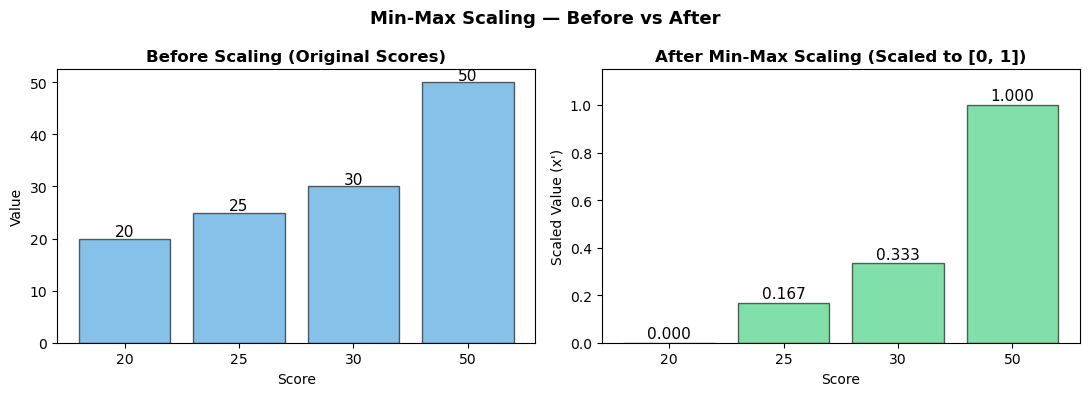

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bar_color = '#3498db'
labels = [str(int(s)) for s in scores]

# Before
axes[0].bar(labels, scores, color=bar_color, alpha=0.6, edgecolor='black')
axes[0].set_title('Before Scaling (Original Scores)', fontweight='bold')
axes[0].set_xlabel('Score');
axes[0].set_ylabel('Value')
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.5, str(int(v)), ha='center', fontsize=11)

# After
axes[1].bar(labels, scaled, color='#2ecc71', alpha=0.6, edgecolor='black')
axes[1].set_title("After Min-Max Scaling (Scaled to [0, 1])", fontweight='bold')
axes[1].set_xlabel('Score');
axes[1].set_ylabel("Scaled Value (x')")
axes[1].set_ylim(0, 1.15)
for i, v in enumerate(scaled):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

plt.suptitle('Min-Max Scaling — Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Chart-এ স্পষ্ট দেখা যাচ্ছে:
- **Before**: মানগুলো 20–50-এর মধ্যে, scale বড়।
- **After**: সব মান 0–1-এর মধ্যে, কিন্তু **relative ব্যবধান হুবহু একই** আছে।

> Min-Max Scaling data-র **shape বা distribution** পরিবর্তন করে না — শুধু **range** পরিবর্তন করে।


---